# <u>Imports</u>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# <u>EDA</u>

In [2]:
df = pd.read_csv("indexProcessed.csv")
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0,333.879006
1,HSI,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0,330.213013
2,HSI,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0,331.811987
3,HSI,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0,335.906987
4,HSI,1987-01-07,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0.0,338.923013


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104224 entries, 0 to 104223
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      104224 non-null  str    
 1   Date       104224 non-null  str    
 2   Open       104224 non-null  float64
 3   High       104224 non-null  float64
 4   Low        104224 non-null  float64
 5   Close      104224 non-null  float64
 6   Adj Close  104224 non-null  float64
 7   Volume     104224 non-null  float64
 8   CloseUSD   104224 non-null  float64
dtypes: float64(7), str(2)
memory usage: 8.6 MB


In [4]:
df.isnull().sum()

Index        0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
CloseUSD     0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0,333.879006
1,HSI,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0,330.213013
2,HSI,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0,331.811987
3,HSI,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0,335.906987
4,HSI,1987-01-07,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0.0,338.923013


# <u>Building the Model</u>

In [7]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (83379, 4)
Testing Data: (20845, 4)


In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
y_pred = model.predict(X_test)
y_pred[:5]

array([  103.68589845, 24258.01730687,  4988.73383877,  4483.09573271,
        4788.53958187])

In [11]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 22.873985881398482
Mean Squared Error: 2364.0289741204806
Root Mean Squared Error: 48.621281082674905
R2 Score: 0.9999710665637896


In [12]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,102.379997,103.685898
1,24301.279300,24258.017307
2,4989.089844,4988.733839
3,4488.000000,4483.095733
4,4835.399902,4788.539582
5,13646.900390,13623.082772
6,774.130005,778.565700
7,9477.669922,9447.134158
8,36120.449220,36165.091430
9,661.369995,661.281917


In [14]:
new_data = [[15000, 15200, 14900, 5000000]]
prediction = model.predict(new_data)
print("Predicted Closing Price:", prediction[0])

Predicted Closing Price: 15087.668147816035


C:\Users\Faraz\OneDrive\course material\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


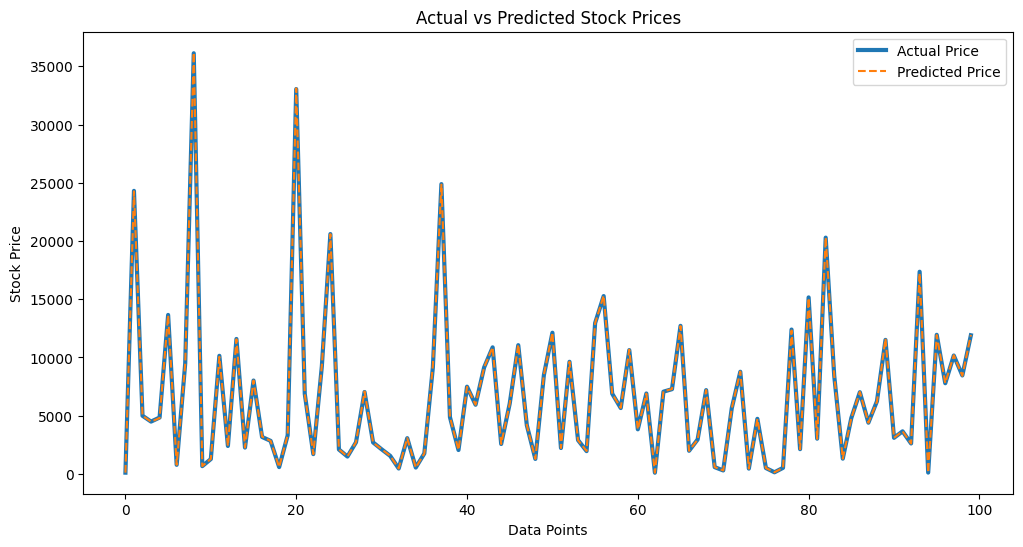

In [17]:
plt.figure(figsize=(12,6))

# Actual prices
plt.plot(
    y_test.values[:100],
    label='Actual Price',
    linewidth=3
)

# Predicted prices
plt.plot(
    y_pred[:100],
    label='Predicted Price',
    linestyle='dashed'
)

plt.legend()

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Data Points")
plt.ylabel("Stock Price")

plt.show()